In [ ]:
# conda install ipywidgets
# conda install tabulate


In [2]:
# Loading Libraries
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
import numpy as np
import os
import cv2
from ipywidgets import widgets
from IPython.display import display
import vision_models.constants as constants
from tabulate import tabulate
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import os
import pydicom
import pandas as pd
from tqdm import tqdm



In [2]:
#Load Data
def load_data():
    train_labels = pd.read_csv(constants.TRAIN_LABEL_PATH)
    train_label_coordinates = pd.read_csv(constants.TRAIN_LABEL_CORD_PATH)
    train_series_descriptions = pd.read_csv(constants.TRAIN_SERIES_DESC_PATH)
    test_series_descriptions = pd.read_csv(constants.TEST_SERIES_DESC_PATH)
    return train_labels, train_label_coordinates, train_series_descriptions, test_series_descriptions

train_labels, train_label_coordinates, train_series_descriptions, test_series_descriptions = load_data()

# Display the first few rows of each DataFrame
print(train_labels.head())
print(train_label_coordinates.head())
print(train_series_descriptions.head())
print(test_series_descriptions.head())

   study_id spinal_canal_stenosis_l1_l2 spinal_canal_stenosis_l2_l3  \
0   4003253                 Normal/Mild                 Normal/Mild   
1   4646740                 Normal/Mild                 Normal/Mild   
2   7143189                 Normal/Mild                 Normal/Mild   
3   8785691                 Normal/Mild                 Normal/Mild   
4  10728036                 Normal/Mild                 Normal/Mild   

  spinal_canal_stenosis_l3_l4 spinal_canal_stenosis_l4_l5  \
0                 Normal/Mild                 Normal/Mild   
1                    Moderate                      Severe   
2                 Normal/Mild                 Normal/Mild   
3                 Normal/Mild                 Normal/Mild   
4                 Normal/Mild                 Normal/Mild   

  spinal_canal_stenosis_l5_s1 left_neural_foraminal_narrowing_l1_l2  \
0                 Normal/Mild                           Normal/Mild   
1                 Normal/Mild                           Normal/M

In [1]:
# Inspecting a single DICOM file

import pydicom

# Example path to a single DICOM file in your train images directory
sample_image_path = "/opt/dataset/train_images/100206310/1012284084/1.dcm"

# Load the DICOM file
dicom_data = pydicom.dcmread(sample_image_path)

# Print out the available metadata
print(dicom_data)


Dataset.file_meta -------------------------------
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: Enhanced MR Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 100206310.1.1
(0002, 0010) Transfer Syntax UID                 UI: RLE Lossless
(0002, 0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002, 0013) Implementation Version Name         SH: 'PYDICOM 2.4.2'
-------------------------------------------------
(0008, 0018) SOP Instance UID                    UI: 100206310.1.1
(0008, 0023) Content Date                        DA: '20240503'
(0008, 0033) Content Time                        TM: '223743.757829'
(0008, 103e) Series Description                  LO: 'T2'
(0010, 0020) Patient ID                          LO: '100206310'
(0018, 0050) Slice Thickness                     DS: '3.5'
(0018, 0088) Spacing Between Slices              DS: '3.5'
(0018, 5100) Patient Position             

In [3]:
# Loading the images

# Paths from the constants.py file
train_data_path = constants.TRAIN_DATA_PATH
test_data_path = constants.TEST_DATA_PATH


In [4]:

# Function to create dataframe with image information
def create_image_dataframe(data_path):
    data = []

    for study_id in tqdm(os.listdir(data_path)):
        study_path = os.path.join(data_path, study_id)
        if os.path.isdir(study_path):
            for series_id in os.listdir(study_path):
                series_path = os.path.join(study_path, series_id)
                if os.path.isdir(series_path):
                    for image_name in os.listdir(series_path):
                        image_path = os.path.join(series_path, image_name)
                        if image_name.endswith('.dcm'):
                            dicom_data = pydicom.dcmread(image_path)

                            # Extract DICOM attributes
                            file_meta_version = dicom_data.file_meta.FileMetaInformationVersion
                            sop_class_uid = dicom_data.file_meta.MediaStorageSOPClassUID
                            sop_instance_uid = dicom_data.file_meta.MediaStorageSOPInstanceUID
                            transfer_syntax_uid = dicom_data.file_meta.TransferSyntaxUID
                            implementation_class_uid = dicom_data.file_meta.ImplementationClassUID
                            implementation_version_name = dicom_data.file_meta.ImplementationVersionName

                            content_date = dicom_data.ContentDate
                            content_time = dicom_data.ContentTime
                            series_description = dicom_data.SeriesDescription
                            patient_id = dicom_data.PatientID
                            slice_thickness = dicom_data.SliceThickness
                            spacing_between_slices = dicom_data.SpacingBetweenSlices
                            patient_position = dicom_data.PatientPosition
                            study_instance_uid = dicom_data.StudyInstanceUID
                            series_instance_uid = dicom_data.SeriesInstanceUID
                            instance_number = dicom_data.InstanceNumber
                            image_position_patient = dicom_data.ImagePositionPatient
                            image_orientation_patient = dicom_data.ImageOrientationPatient
                            frame_of_reference_uid = dicom_data.FrameOfReferenceUID
                            slice_location = dicom_data.SliceLocation
                            samples_per_pixel = dicom_data.SamplesPerPixel
                            photometric_interpretation = dicom_data.PhotometricInterpretation
                            rows = dicom_data.Rows
                            columns = dicom_data.Columns
                            pixel_spacing = dicom_data.PixelSpacing
                            bits_allocated = dicom_data.BitsAllocated
                            bits_stored = dicom_data.BitsStored
                            high_bit = dicom_data.HighBit
                            pixel_representation = dicom_data.PixelRepresentation
                            window_center = dicom_data.WindowCenter
                            window_width = dicom_data.WindowWidth

                            # Add the extracted data to the list
                            data.append({
                                'study_id': study_id,
                                'series_id': series_id,
                                'image_name': image_name,
                                'file_meta_version': file_meta_version,
                                'sop_class_uid': sop_class_uid,
                                'sop_instance_uid': sop_instance_uid,
                                'transfer_syntax_uid': transfer_syntax_uid,
                                'implementation_class_uid': implementation_class_uid,
                                'implementation_version_name': implementation_version_name,
                                'content_date': content_date,
                                'content_time': content_time,
                                'series_description': series_description,
                                'patient_id': patient_id,
                                'slice_thickness': slice_thickness,
                                'spacing_between_slices': spacing_between_slices,
                                'patient_position': patient_position,
                                'study_instance_uid': study_instance_uid,
                                'series_instance_uid': series_instance_uid,
                                'instance_number': instance_number,
                                'image_position_patient': image_position_patient,
                                'image_orientation_patient': image_orientation_patient,
                                'frame_of_reference_uid': frame_of_reference_uid,
                                'slice_location': slice_location,
                                'samples_per_pixel': samples_per_pixel,
                                'photometric_interpretation': photometric_interpretation,
                                'rows': rows,
                                'columns': columns,
                                'pixel_spacing': pixel_spacing,
                                'bits_allocated': bits_allocated,
                                'bits_stored': bits_stored,
                                'high_bit': high_bit,
                                'pixel_representation': pixel_representation,
                                'window_center': window_center,
                                'window_width': window_width,
                            })

    # Convert the list of dictionaries to a DataFrame
    df = pd.DataFrame(data)
    return df

# Create dataframes for train and test images
train_image_df = create_image_dataframe(train_data_path)
test_image_df = create_image_dataframe(test_data_path)

# Display the first few rows of each dataframe
print(train_image_df.head())
print(test_image_df.head())

  0%|          | 0/1975 [00:00<?, ?it/s]

 10%|▉         | 197/1975 [00:54<08:10,  3.62it/s]


KeyboardInterrupt: 

In [23]:
print(train_image_df.shape)
print(test_image_df.shape)


(147218, 34)
(97, 34)


In [ ]:
# # Perform the left join between train_label_coordinates and train_series_descriptions
# merged_labels_df = pd.merge(train_label_coordinates, train_series_descriptions, on=['study_id', 'series_id'], how='left')
# # Convert 'study_id' and 'series_id' columns to strings
# merged_labels_df['study_id'] = merged_labels_df['study_id'].astype(str)
# merged_labels_df['series_id'] = merged_labels_df['series_id'].astype(str)
# merged_labels_df['instance_number'] = merged_labels_df['instance_number'].astype(int).astype(str)

# Convert 'study_id' and 'series_id' columns to strings
train_label_coordinates['study_id'] = train_label_coordinates['study_id'].astype(str)
train_label_coordinates['series_id'] = train_label_coordinates['series_id'].astype(str)
train_label_coordinates['instance_number'] = train_label_coordinates['instance_number'].astype(int).astype(str)
print(train_label_coordinates.head())
print('train_label_coordinates:', train_label_coordinates.shape)

# Now merge the result with train_image_df
# We will merge on 'study_id', 'series_id', and 'instance_number' (matching the `image_name` in train_image_df)
# Assuming that 'instance_number' in train_label_coordinates corresponds to the 'image_name' in train_image_df
train_image_df['instance_number'] = train_image_df['image_name'].str.replace('.dcm', '').astype(int).astype(str)
# Convert 'study_id' and 'series_id' columns to strings
train_image_df['study_id'] = train_image_df['study_id'].astype(str)
train_image_df['series_id'] = train_image_df['series_id'].astype(str)

print(train_image_df.head())
print('train images:', train_image_df.shape)

# Perform the final merge
final_train_df = pd.merge(train_image_df, train_label_coordinates, on=['study_id', 'series_id','instance_number'], how='left')

# Display the result

print(final_train_df.head())
print('final train df:',final_train_df.shape)


  study_id  series_id instance_number              condition  level  \
0  4003253  702807833               8  Spinal Canal Stenosis  L1/L2   
1  4003253  702807833               8  Spinal Canal Stenosis  L2/L3   
2  4003253  702807833               8  Spinal Canal Stenosis  L3/L4   
3  4003253  702807833               8  Spinal Canal Stenosis  L4/L5   
4  4003253  702807833               8  Spinal Canal Stenosis  L5/S1   

            x           y  
0  322.831858  227.964602  
1  320.571429  295.714286  
2  323.030303  371.818182  
3  335.292035  427.327434  
4  353.415929  483.964602  
train_label_coordinates: (48692, 7)
     study_id   series_id image_name file_meta_version  \
0  3521159632  3530159983     11.dcm       b'\x00\x01'   
1  3521159632  3530159983     18.dcm       b'\x00\x01'   
2  3521159632  3530159983     12.dcm       b'\x00\x01'   
3  3521159632  3530159983     47.dcm       b'\x00\x01'   
4  3521159632  3530159983     32.dcm       b'\x00\x01'   

                 sop

In [30]:
print('train_label_coordinates:', train_label_coordinates.columns)
print('train_image_df:', train_image_df.columns)
print('final_train_df:', final_train_df.columns)

train_label_coordinates: Index(['study_id', 'series_id', 'instance_number', 'condition', 'level', 'x',
       'y'],
      dtype='object')
train_image_df: Index(['study_id', 'series_id', 'image_name', 'file_meta_version',
       'sop_class_uid', 'sop_instance_uid', 'transfer_syntax_uid',
       'implementation_class_uid', 'implementation_version_name',
       'content_date', 'content_time', 'series_description', 'patient_id',
       'slice_thickness', 'spacing_between_slices', 'patient_position',
       'study_instance_uid', 'series_instance_uid', 'instance_number',
       'image_position_patient', 'image_orientation_patient',
       'frame_of_reference_uid', 'slice_location', 'samples_per_pixel',
       'photometric_interpretation', 'rows', 'columns', 'pixel_spacing',
       'bits_allocated', 'bits_stored', 'high_bit', 'pixel_representation',
       'window_center', 'window_width'],
      dtype='object')
final_train_df: Index(['study_id', 'series_id', 'image_name', 'file_meta_version',

In [ ]:
# The number of rows of images with a condition and level and without any condition or level

print(final_train_df.shape)
print(final_train_df.head())



(171364, 38)
     study_id   series_id image_name file_meta_version  \
0  3521159632  3530159983     11.dcm       b'\x00\x01'   
1  3521159632  3530159983     18.dcm       b'\x00\x01'   
2  3521159632  3530159983     12.dcm       b'\x00\x01'   
3  3521159632  3530159983     47.dcm       b'\x00\x01'   
4  3521159632  3530159983     32.dcm       b'\x00\x01'   

                 sop_class_uid sop_instance_uid  transfer_syntax_uid  \
0  1.2.840.10008.5.1.4.1.1.4.1  3521159632.1.11  1.2.840.10008.1.2.5   
1  1.2.840.10008.5.1.4.1.1.4.1  3521159632.1.18  1.2.840.10008.1.2.5   
2  1.2.840.10008.5.1.4.1.1.4.1  3521159632.1.12  1.2.840.10008.1.2.5   
3  1.2.840.10008.5.1.4.1.1.4.1  3521159632.1.47  1.2.840.10008.1.2.5   
4  1.2.840.10008.5.1.4.1.1.4.1  3521159632.1.32  1.2.840.10008.1.2.5   

  implementation_class_uid implementation_version_name content_date  ...  \
0        1.2.40.0.13.1.1.1               PYDICOM 2.4.2     20240503  ...   
1        1.2.40.0.13.1.1.1               PYDICOM 2.4.

In [ ]:
# Check for duplicates based on key columns, there should be 24146 duplicates because one image can have multiple conditions
duplicates = final_train_df[final_train_df.duplicated(subset=['study_id', 'series_id', 'instance_number'])]
print(duplicates.shape)

(24146, 38)


In [ ]:
# Group by 'study_id', 'series_id', 'image_name' to see how many conditions/labels are associated with each image
condition_counts = final_train_df.groupby(['study_id', 'series_id', 'instance_number']).size()
print(condition_counts.describe())


count    147218.000000
mean          1.164015
std           0.628949
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          10.000000
dtype: float64


In [ ]:
# Group by 'study_id', 'series_id', 'image_name' to see how many conditions/labels are associated with each image
condition_counts = final_train_df.groupby(['study_id', 'series_id', 'image_name']).size()
print(condition_counts.describe())


count    147218.000000
mean          1.164015
std           0.628949
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          10.000000
dtype: float64


In [ ]:
# Aggregating conditions and labels
aggregated_df = final_train_df.groupby(['study_id', 'series_id', 'image_name']).agg({
    'condition': lambda x: list(x),
    'level': lambda x: list(x),
    'x': lambda x: list(x),
    'y': lambda x: list(x),
    # Include other columns if necessary
}).reset_index()

print(aggregated_df.head())
print(aggregated_df.shape)


    study_id   series_id image_name condition  level      x      y
0  100206310  1012284084      1.dcm     [nan]  [nan]  [nan]  [nan]
1  100206310  1012284084     10.dcm     [nan]  [nan]  [nan]  [nan]
2  100206310  1012284084     11.dcm     [nan]  [nan]  [nan]  [nan]
3  100206310  1012284084     12.dcm     [nan]  [nan]  [nan]  [nan]
4  100206310  1012284084     13.dcm     [nan]  [nan]  [nan]  [nan]
(147218, 7)


In [ ]:
# Example inspection of a specific case
specific_case = final_train_df[(final_train_df['study_id'] == 'some_study_id') & 
                               (final_train_df['series_id'] == 'some_series_id') & 
                               (final_train_df['image_name'] == 'some_image_name')]
print(specific_case)


Empty DataFrame
Columns: [study_id, series_id, image_name, file_meta_version, sop_class_uid, sop_instance_uid, transfer_syntax_uid, implementation_class_uid, implementation_version_name, content_date, content_time, series_description, patient_id, slice_thickness, spacing_between_slices, patient_position, study_instance_uid, series_instance_uid, instance_number, image_position_patient, image_orientation_patient, frame_of_reference_uid, slice_location, samples_per_pixel, photometric_interpretation, rows, columns, pixel_spacing, bits_allocated, bits_stored, high_bit, pixel_representation, window_center, window_width, condition, level, x, y]
Index: []

[0 rows x 38 columns]


In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split

train_split = constants.TRAIN_SPLIT
val_split = constants.VAL_SPLIT
test_split = constants.TEST_SPLIT


In [52]:
# Assuming final_train_df is already loaded and contains 'study_id' and 'condition'

# Group by study_id to get the dominant condition per study_id
def get_dominant_condition(conditions):
    mode = conditions.mode()
    if not mode.empty:
        return mode[0]  # Return the mode if it exists
    else:
        return conditions.iloc[0]  # Fallback to the first condition if mode is empty

study_groups = final_train_df.groupby('study_id').agg({
    'condition': lambda x: get_dominant_condition(x)
}).reset_index()

# Check for NaN values in the condition column
print(f"Number of NaN conditions: {study_groups['condition'].isna().sum()}")

# Drop rows where condition is NaN
study_groups = study_groups.dropna(subset=['condition'])

# Perform the stratified split based on the dominant condition for the initial train/test split
train_studies, temp_studies = train_test_split(study_groups['study_id'], test_size=(1 - train_split), 
                                               stratify=study_groups['condition'], random_state=42)

# From the remaining studies, split into validation and test sets
val_studies, test_studies = train_test_split(temp_studies, test_size=(test_split / (val_split + test_split)), 
                                             stratify=study_groups.loc[study_groups['study_id'].isin(temp_studies), 'condition'], 
                                             random_state=42)

# Now, filter the final_train_df for each split
train_df = final_train_df[final_train_df['study_id'].isin(train_studies)]
val_df = final_train_df[final_train_df['study_id'].isin(val_studies)]
test_df = final_train_df[final_train_df['study_id'].isin(test_studies)]

# Print the shapes of the resulting datasets
print(f'Train dataset shape: {train_df.shape}')
print(f'Validation dataset shape: {val_df.shape}')
print(f'Test dataset shape: {test_df.shape}')

# Check the balance of conditions in each dataset
print(f'Train conditions distribution:\n{train_df["condition"].value_counts(normalize=True)}\n')
print(f'Validation conditions distribution:\n{val_df["condition"].value_counts(normalize=True)}\n')
print(f'Test conditions distribution:\n{test_df["condition"].value_counts(normalize=True)}\n')

Number of NaN conditions: 1
Train dataset shape: (137076, 38)
Validation dataset shape: (16810, 38)
Test dataset shape: (17391, 38)
Train conditions distribution:
condition
Left Neural Foraminal Narrowing     0.202538
Right Neural Foraminal Narrowing    0.202512
Spinal Canal Stenosis               0.200380
Right Subarticular Stenosis         0.197323
Left Subarticular Stenosis          0.197246
Name: proportion, dtype: float64

Validation conditions distribution:
condition
Right Neural Foraminal Narrowing    0.203344
Left Neural Foraminal Narrowing     0.203344
Spinal Canal Stenosis               0.200454
Left Subarticular Stenosis          0.196532
Right Subarticular Stenosis         0.196325
Name: proportion, dtype: float64

Test conditions distribution:
condition
Left Neural Foraminal Narrowing     0.201342
Right Neural Foraminal Narrowing    0.201342
Spinal Canal Stenosis               0.199512
Right Subarticular Stenosis         0.199105
Left Subarticular Stenosis          0.19869

/var/tmp/ipykernel_200761/1544499900.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=condition_counts.index, y=condition_counts.values, palette="viridis")


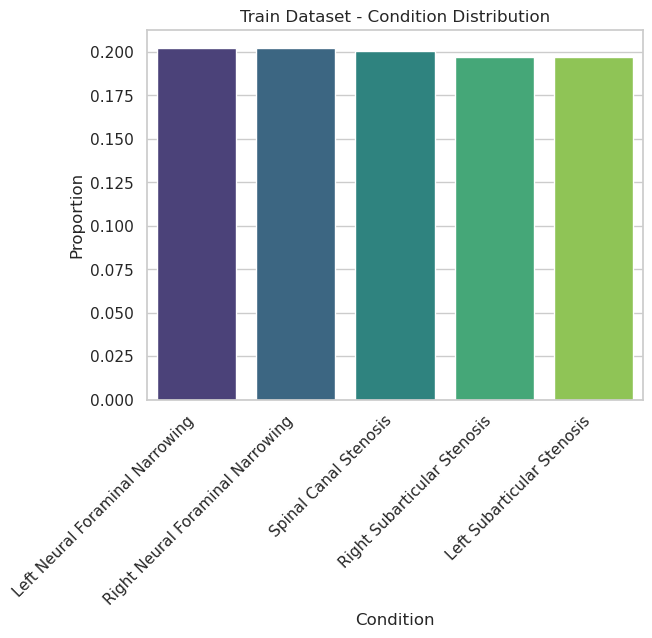

/var/tmp/ipykernel_200761/1544499900.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=condition_counts.index, y=condition_counts.values, palette="viridis")


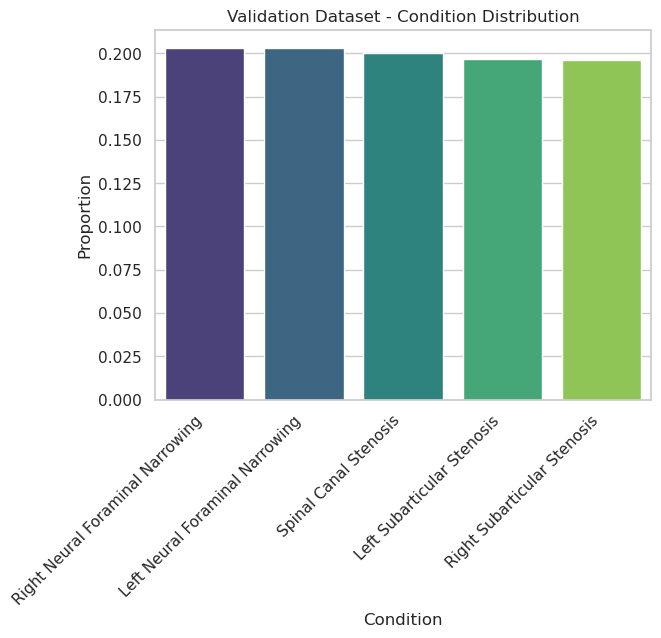

/var/tmp/ipykernel_200761/1544499900.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=condition_counts.index, y=condition_counts.values, palette="viridis")


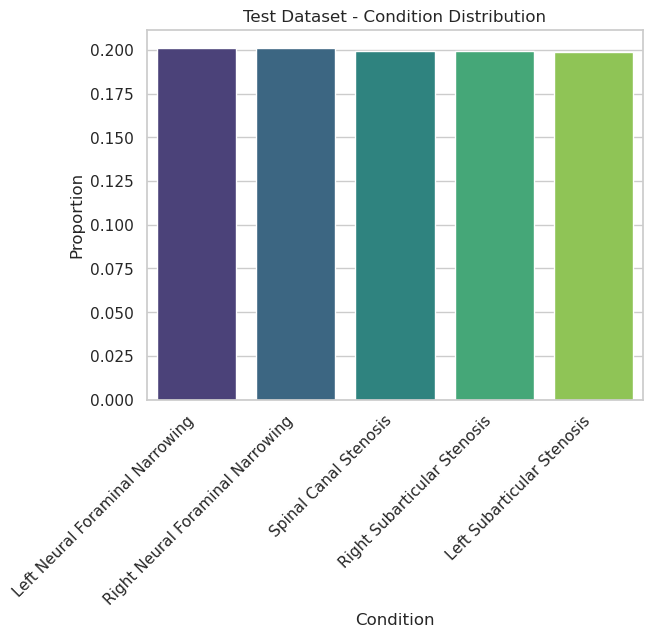

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set(style="whitegrid")

# Function to plot the condition distribution
def plot_condition_distribution(df, title):
    condition_counts = df['condition'].value_counts(normalize=True)
    sns.barplot(x=condition_counts.index, y=condition_counts.values, palette="viridis")
    plt.title(title)
    plt.xlabel('Condition')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45, ha="right")
    plt.show()

# Plot the distribution of conditions in the train dataset
plot_condition_distribution(train_df, "Train Dataset - Condition Distribution")

# Plot the distribution of conditions in the validation dataset
plot_condition_distribution(val_df, "Validation Dataset - Condition Distribution")

# Plot the distribution of conditions in the test dataset
plot_condition_distribution(test_df, "Test Dataset - Condition Distribution")


/var/tmp/ipykernel_200761/2268222314.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=level_counts.index, y=level_counts.values, palette="viridis")


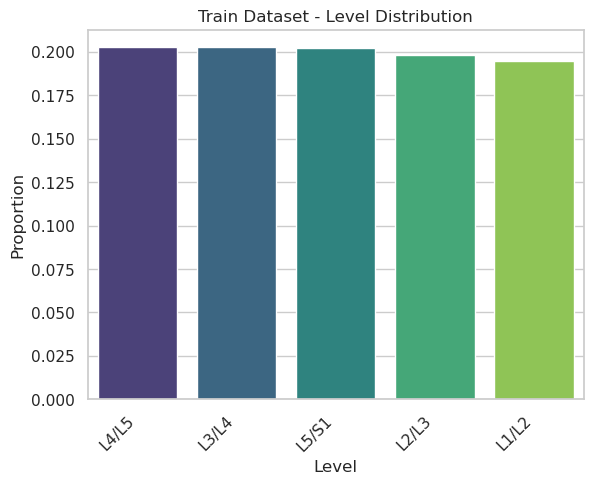

/var/tmp/ipykernel_200761/2268222314.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=level_counts.index, y=level_counts.values, palette="viridis")


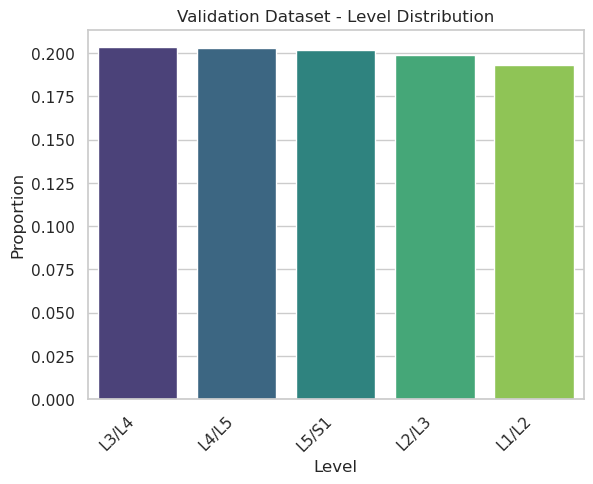

/var/tmp/ipykernel_200761/2268222314.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=level_counts.index, y=level_counts.values, palette="viridis")


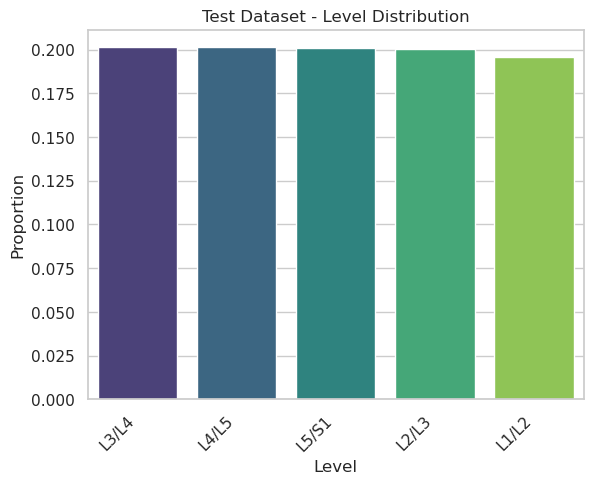

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set(style="whitegrid")

# Function to plot the level distribution
def plot_level_distribution(df, title):
    level_counts = df['level'].value_counts(normalize=True)
    sns.barplot(x=level_counts.index, y=level_counts.values, palette="viridis")
    plt.title(title)
    plt.xlabel('Level')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45, ha="right")
    plt.show()

# Plot the distribution of levels in the train dataset
plot_level_distribution(train_df, "Train Dataset - Level Distribution")

# Plot the distribution of levels in the validation dataset
plot_level_distribution(val_df, "Validation Dataset - Level Distribution")

# Plot the distribution of levels in the test dataset
plot_level_distribution(test_df, "Test Dataset - Level Distribution")


/var/tmp/ipykernel_200761/3816536477.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=condition_counts.index, y=condition_counts.values, palette="viridis")


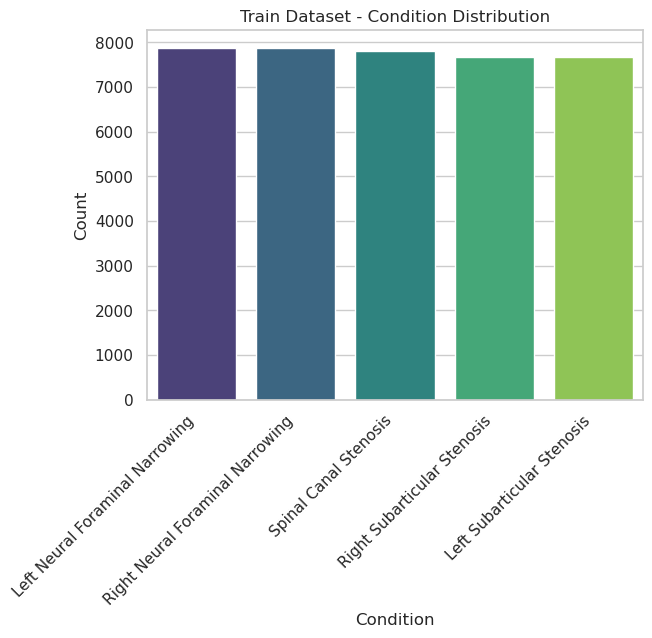

/var/tmp/ipykernel_200761/3816536477.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=condition_counts.index, y=condition_counts.values, palette="viridis")


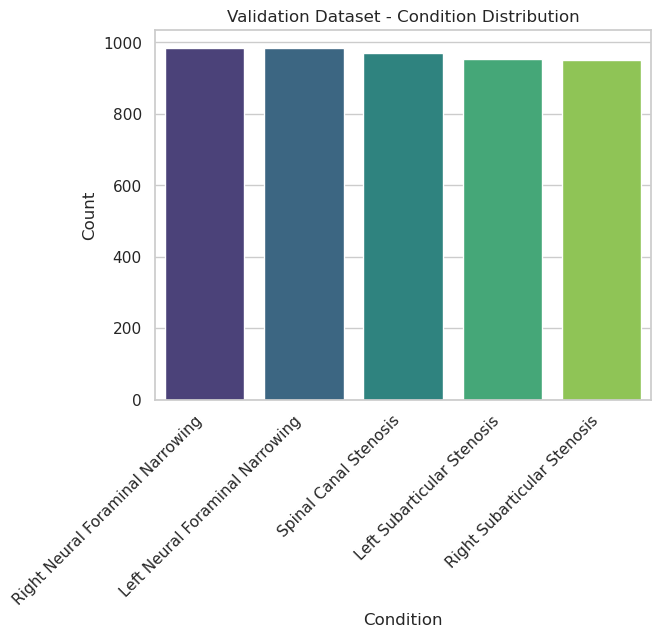

/var/tmp/ipykernel_200761/3816536477.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=condition_counts.index, y=condition_counts.values, palette="viridis")


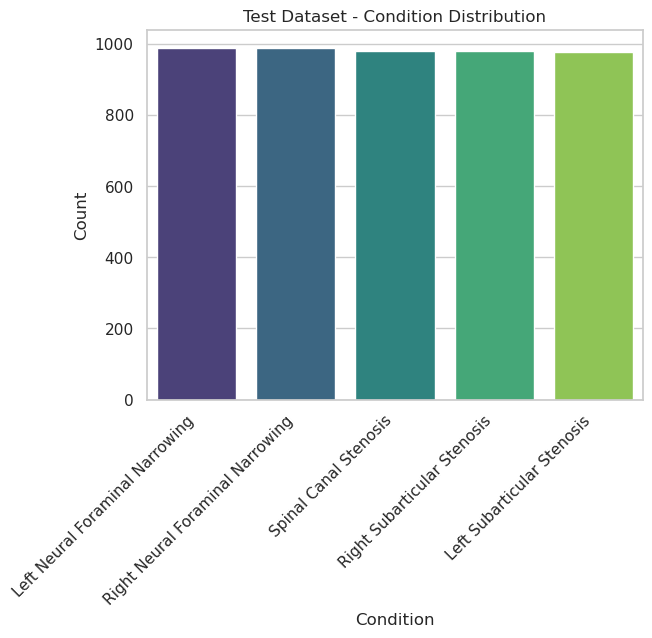

/var/tmp/ipykernel_200761/3816536477.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=level_counts.index, y=level_counts.values, palette="viridis")


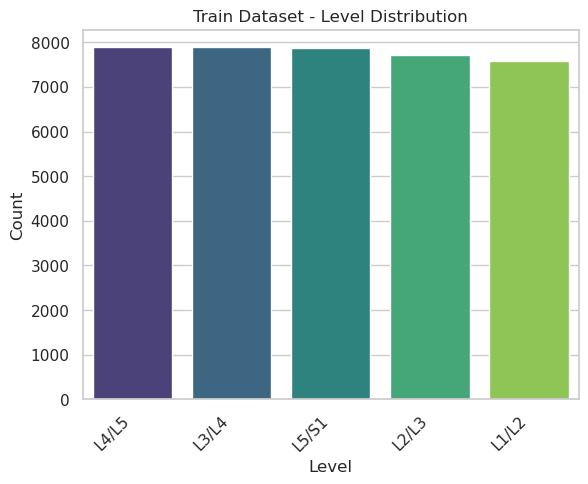

/var/tmp/ipykernel_200761/3816536477.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=level_counts.index, y=level_counts.values, palette="viridis")


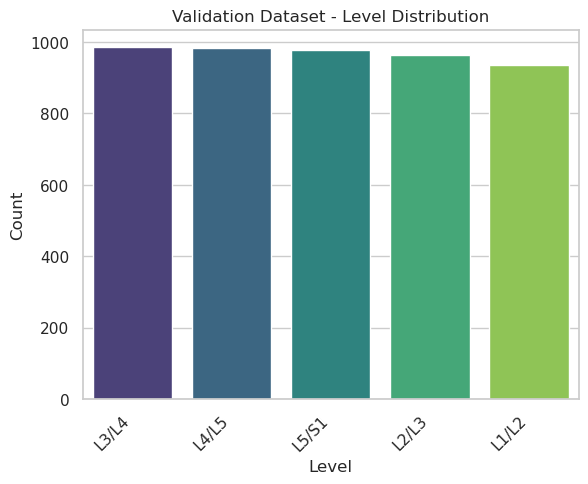

/var/tmp/ipykernel_200761/3816536477.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=level_counts.index, y=level_counts.values, palette="viridis")


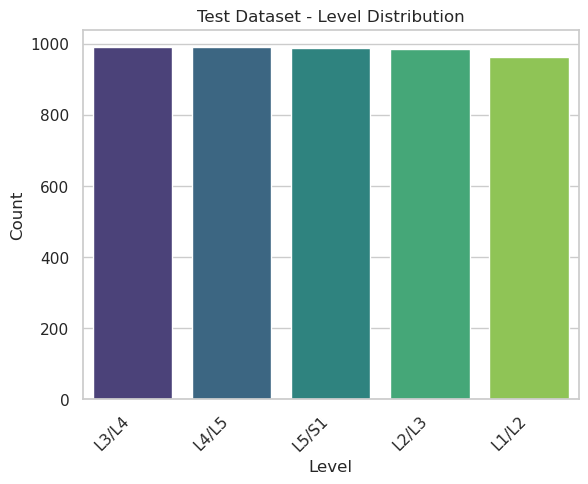

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set(style="whitegrid")

# Function to plot the condition distribution with counts
def plot_condition_distribution(df, title):
    condition_counts = df['condition'].value_counts()
    sns.barplot(x=condition_counts.index, y=condition_counts.values, palette="viridis")
    plt.title(title)
    plt.xlabel('Condition')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha="right")
    plt.show()

# Function to plot the level distribution with counts
def plot_level_distribution(df, title):
    level_counts = df['level'].value_counts()
    sns.barplot(x=level_counts.index, y=level_counts.values, palette="viridis")
    plt.title(title)
    plt.xlabel('Level')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha="right")
    plt.show()

# Plot the distribution of conditions in the train, validation, and test datasets
plot_condition_distribution(train_df, "Train Dataset - Condition Distribution")
plot_condition_distribution(val_df, "Validation Dataset - Condition Distribution")
plot_condition_distribution(test_df, "Test Dataset - Condition Distribution")

# Plot the distribution of levels in the train, validation, and test datasets
plot_level_distribution(train_df, "Train Dataset - Level Distribution")
plot_level_distribution(val_df, "Validation Dataset - Level Distribution")
plot_level_distribution(test_df, "Test Dataset - Level Distribution")


In [57]:
# Define the file paths for saving
train_csv_path = "NEW_EDA/train_dataset.csv"
val_csv_path = "NEW_EDA/val_dataset.csv"
test_csv_path = "NEW_EDA/test_dataset.csv"

# Export the train dataframe to a CSV file
train_df.to_csv(train_csv_path, index=False)

# Export the validation dataframe to a CSV file
val_df.to_csv(val_csv_path, index=False)

# Export the test dataframe to a CSV file
test_df.to_csv(test_csv_path, index=False)

print("Data splits exported successfully!")


Data splits exported successfully!
